In [ ]:
from google.colab import drive
try:
  drive.mount('/content/drive')
  print('Kết nối với Drive thành công')
except Exception as ex:
  print(f'Có lỗi khi kết nối: {ex}')
  exit()



Mounted at /content/drive
Kết nối với Drive thành công


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Dang quet du lieu: /content/drive/MyDrive/HK1-20252026/Steganography/Data/audio-cats-and-dogs
Da xu ly xong 277 file.


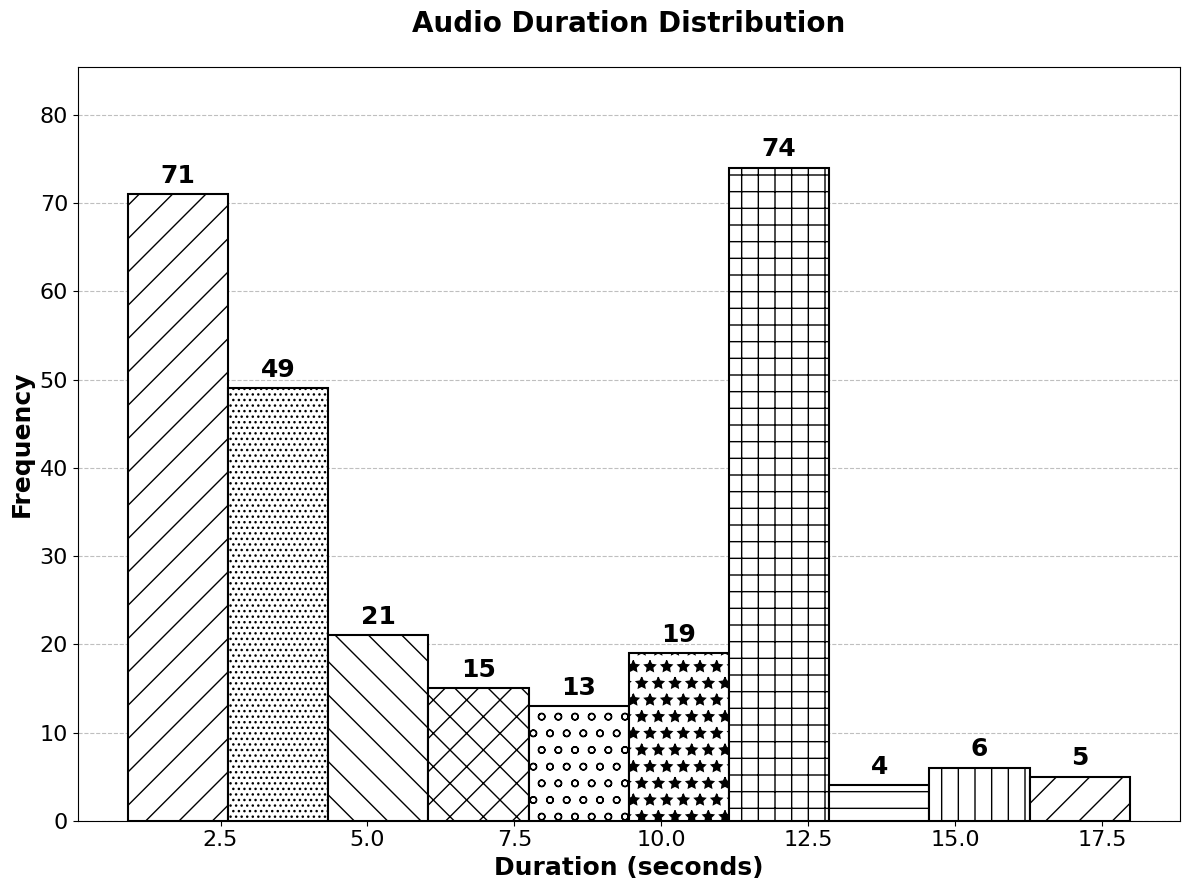

Da luu bieu do: Histogram_Duration_Recursive.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pydub import AudioSegment
import warnings

warnings.filterwarnings("ignore")

folder_path = '/content/drive/MyDrive/HK1-20252026/Steganography/Data/audio-cats-and-dogs'
output_image = 'Histogram_Duration_Recursive.png'

data = []

if os.path.exists(folder_path):
    print(f"Dang quet du lieu: {folder_path}")

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.wav', '.mp3', '.flac', '.ogg', '.m4a')):
                filepath = os.path.join(root, filename)
                try:
                    audio = AudioSegment.from_file(filepath)
                    data.append(audio.duration_seconds)
                except:
                    continue

    print(f"Da xu ly xong {len(data)} file.")
else:
    print(f"Thu muc khong ton tai: {folder_path}")

if data:
    df = pd.DataFrame(data, columns=['Duration'])

    fig, ax = plt.subplots(figsize=(12, 9))

    num_bins = int(np.ceil(np.log2(len(df)) + 1))
    if num_bins < 5: num_bins = 5

    counts, bins, patches = ax.hist(df['Duration'], bins=num_bins,
                                    color='white', edgecolor='black', linewidth=1.5)

    patterns = ['/', '...', '\\', 'x', 'o', '*', '+', '-', '|']

    for i, patch in enumerate(patches):
        pattern = patterns[i % len(patterns)]
        patch.set_hatch(pattern)

    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1] * 1.1)

    for count, patch in zip(counts, patches):
        if count > 0:
            height = patch.get_height()
            x_pos = patch.get_x() + patch.get_width() / 2
            ax.text(x_pos, height + (max(counts) * 0.01),
                    f'{int(count)}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')

    ax.set_xlabel('Duration (seconds)', fontsize=18, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=18, fontweight='bold')
    ax.set_title('Audio Duration Distribution', fontsize=20, fontweight='bold', pad=25)

    ax.tick_params(axis='both', which='major', labelsize=16)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', color='grey', alpha=0.5)

    plt.tight_layout()
    plt.savefig(output_image, dpi=300)
    plt.show()
    print(f"Da luu bieu do: {output_image}")
else:
    print("Khong tim thay du lieu audio hop le.")

Dang quet du lieu: /content/drive/MyDrive/HK1-20252026/Steganography/Data/musdb18-hq
Da xu ly xong 750 file.


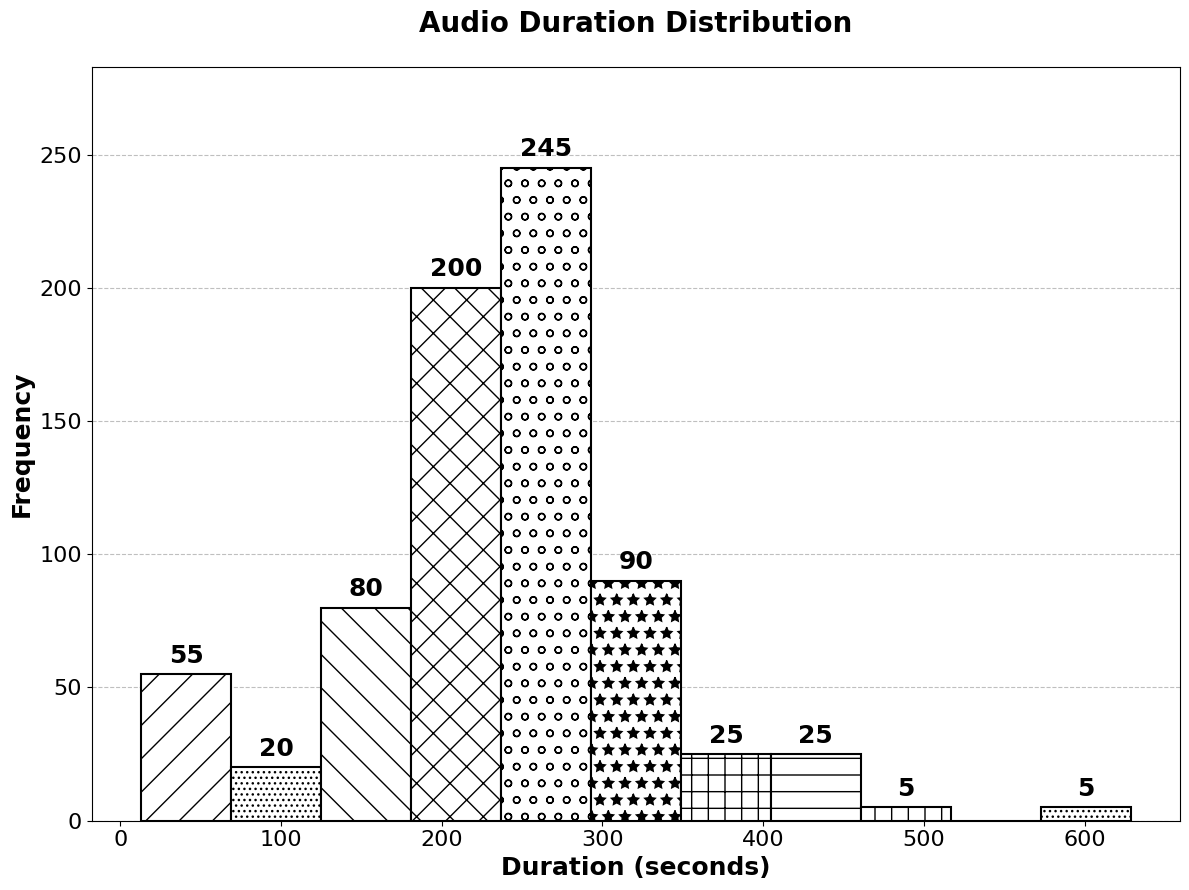

Da luu bieu do: Histogram_Duration_Optimized.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import librosa
import warnings

warnings.filterwarnings("ignore")

folder_path = '/content/drive/MyDrive/HK1-20252026/Steganography/Data/musdb18-hq'
output_image = 'Histogram_Duration_Optimized.png'

data = []

if os.path.exists(folder_path):
    print(f"Dang quet du lieu: {folder_path}")

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.wav', '.mp3', '.flac', '.ogg', '.m4a')):
                filepath = os.path.join(root, filename)
                try:
                    duration = librosa.get_duration(path=filepath)
                    data.append(duration)
                except TypeError:
                    try:
                        duration = librosa.get_duration(filename=filepath)
                        data.append(duration)
                    except:
                        continue
                except:
                    continue

    print(f"Da xu ly xong {len(data)} file.")
else:
    print(f"Thu muc khong ton tai: {folder_path}")

if data:
    df = pd.DataFrame(data, columns=['Duration'])

    fig, ax = plt.subplots(figsize=(12, 9))

    num_bins = int(np.ceil(np.log2(len(df)) + 1))
    if num_bins < 5: num_bins = 5

    counts, bins, patches = ax.hist(df['Duration'], bins=num_bins,
                                    color='white', edgecolor='black', linewidth=1.5)

    patterns = ['/', '...', '\\', 'x', 'o', '*', '+', '-', '|']

    for i, patch in enumerate(patches):
        pattern = patterns[i % len(patterns)]
        patch.set_hatch(pattern)

    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1] * 1.1)

    for count, patch in zip(counts, patches):
        if count > 0:
            height = patch.get_height()
            x_pos = patch.get_x() + patch.get_width() / 2
            ax.text(x_pos, height + (max(counts) * 0.01),
                    f'{int(count)}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')

    ax.set_xlabel('Duration (seconds)', fontsize=18, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=18, fontweight='bold')
    ax.set_title('Audio Duration Distribution', fontsize=20, fontweight='bold', pad=25)

    ax.tick_params(axis='both', which='major', labelsize=16)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', color='grey', alpha=0.5)

    plt.tight_layout()
    plt.savefig(output_image, dpi=300)
    plt.show()
    print(f"Da luu bieu do: {output_image}")
else:
    print("Khong tim thay du lieu audio hop le.")

Dang quet danh sach file trong: /content/drive/MyDrive/HK2-20252026/data/timit ...
-> Tim thay tong cong: 12600 file.
Dang doc thong tin 12600 file (Multi-threading)...


100%|██████████| 12600/12600 [02:36<00:00, 80.39file/s]



 BÁO CÁO THỐNG KÊ (Processed: 12600 files)
Tần số lấy mẫu: 16000 Hz
Độ sâu bit:     16-bit
Số kênh:        1 (Mono)
--------------------------------------------------
Min Duration:   0.9153s
Max Duration:   7.7888s
Avg Duration:   3.0761s
Total Duration: 10.77h (38759.46s)



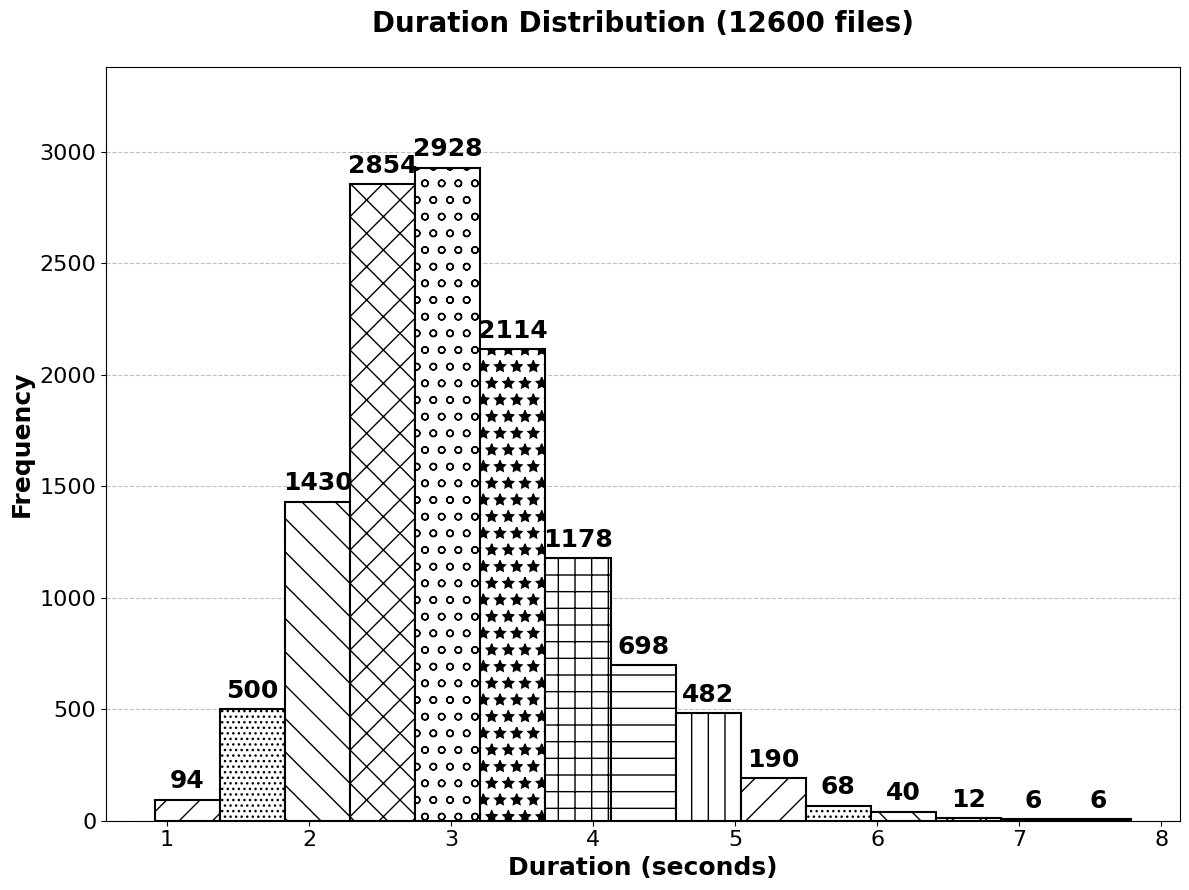

Da luu bieu do: Histogram_Duration_Optimized.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import warnings
import concurrent.futures  # Thư viện xử lý đa luồng
from tqdm import tqdm      # Thư viện tạo thanh tiến trình
import random

warnings.filterwarnings("ignore")

# --- CẤU HÌNH ---
folder_path = '/content/drive/MyDrive/HK2-20252026/data/timit'
output_image = 'Histogram_Duration_Optimized.png'
SAMPLE_SIZE = None

def process_single_file(filepath):
    try:
        info = sf.info(filepath)
        return {
            'Duration': info.duration,
            'Sample Rate': info.samplerate,
            'Channels': info.channels,
            'Bit Depth': info.subtype
        }
    except:
        return None

all_files = []
if os.path.exists(folder_path):
    print(f"Dang quet danh sach file trong: {folder_path} ...")
    # os.walk bản chất đã nhanh, ta gom hết path vào list trước
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.wav', '.flac', '.ogg', '.aiff', '.au')):
                all_files.append(os.path.join(root, filename))
    print(f"-> Tim thay tong cong: {len(all_files)} file.")
else:
    print(f"Thu muc khong ton tai: {folder_path}")
    exit()

target_files = []
if SAMPLE_SIZE and len(all_files) > SAMPLE_SIZE:
    print(f"-> Dang chon ngau nhien {SAMPLE_SIZE} file de xu ly...")
    target_files = random.sample(all_files, SAMPLE_SIZE)
else:
    target_files = all_files # Xử lý hết

data_details = []
print(f"Dang doc thong tin {len(target_files)} file (Multi-threading)...")

with concurrent.futures.ThreadPoolExecutor(max_workers=16) as executor:
    # Dùng tqdm để bọc thanh tiến trình
    results = list(tqdm(executor.map(process_single_file, target_files), total=len(target_files), unit="file"))

# Lọc bỏ các kết quả lỗi (None)
data_details = [r for r in results if r is not None]

if data_details:
    df = pd.DataFrame(data_details)

    # Mapping Bit Depth
    def format_bit_depth(subtype):
        if 'PCM_16' in subtype: return '16-bit'
        if 'PCM_24' in subtype: return '24-bit'
        if 'PCM_32' in subtype: return '32-bit'
        if 'FLOAT' in subtype: return '32-bit Float'
        return subtype

    df['Bit Depth Readable'] = df['Bit Depth'].apply(format_bit_depth)

    # Tính toán chỉ số
    unique_sr = df['Sample Rate'].unique()
    unique_bits = df['Bit Depth Readable'].unique()
    unique_channels = df['Channels'].unique()

    channel_str = []
    for c in unique_channels:
        if c == 1: channel_str.append("1 (Mono)")
        elif c == 2: channel_str.append("2 (Stereo)")
        else: channel_str.append(f"{c} channels")

    total_duration_sec = df['Duration'].sum()
    total_hours = total_duration_sec / 3600

    print("\n" + "="*50)
    print(f" BÁO CÁO THỐNG KÊ (Processed: {len(df)} files)")
    print("="*50)
    print(f"Tần số lấy mẫu: {', '.join(map(str, unique_sr))} Hz")
    print(f"Độ sâu bit:     {', '.join(unique_bits)}")
    print(f"Số kênh:        {', '.join(channel_str)}")
    print("-" * 50)
    print(f"Min Duration:   {df['Duration'].min():.4f}s")
    print(f"Max Duration:   {df['Duration'].max():.4f}s")
    print(f"Avg Duration:   {df['Duration'].mean():.4f}s")
    print(f"Total Duration: {total_hours:.2f}h ({total_duration_sec:.2f}s)")
    print("="*50 + "\n")

    # Vẽ biểu đồ
    fig, ax = plt.subplots(figsize=(12, 9))
    num_bins = int(np.ceil(np.log2(len(df)) + 1))
    if num_bins < 5: num_bins = 5
    if df['Duration'].std() < 1 and num_bins < 15: num_bins = 15

    counts, bins, patches = ax.hist(df['Duration'], bins=num_bins,
                                    color='white', edgecolor='black', linewidth=1.5)

    patterns = ['/', '...', '\\', 'x', 'o', '*', '+', '-', '|']
    for i, patch in enumerate(patches):
        patch.set_hatch(patterns[i % len(patterns)])

    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1] * 1.1)

    for count, patch in zip(counts, patches):
        if count > 0:
            height = patch.get_height()
            x_pos = patch.get_x() + patch.get_width() / 2
            ax.text(x_pos, height + (max(counts) * 0.01),
                    f'{int(count)}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')

    ax.set_xlabel('Duration (seconds)', fontsize=18, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=18, fontweight='bold')
    ax.set_title(f'Duration Distribution ({len(df)} files)', fontsize=20, fontweight='bold', pad=25)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', color='grey', alpha=0.5)

    plt.tight_layout()
    plt.savefig(output_image, dpi=300)
    plt.show()
    print(f"Da luu bieu do: {output_image}")
else:
    print("Khong tim thay du lieu hoac loi doc file.")